In [2]:
import pandas as pd
import anndata as ad
from anndata import read_zarr
import numpy as np
import scanpy as sc


In [3]:
adata = read_zarr("../integration/Integrated.zarr")

In [4]:
adata.layers["SCVI_log"] =  np.log(adata.layers["SCVI_normalized"] + 1)

pocessing has all been done so this is just for making each of the differet plots we want to see

<positron-console-cell-5>:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.


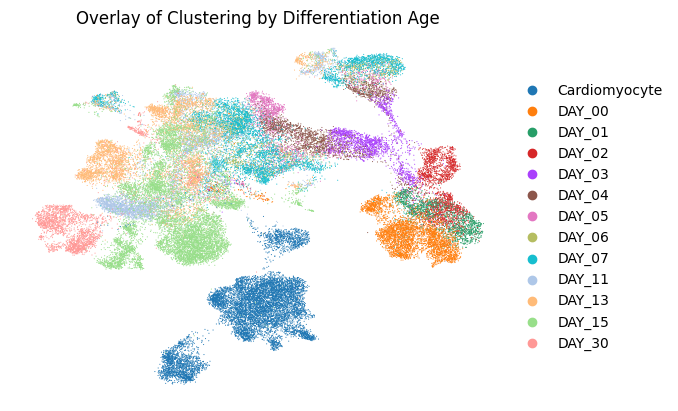

In [5]:
sc.pl.umap(
    adata,
    title = "Overlay of Clustering by Differentiation Age",
    color="Day",
    frameon=False,
    ncols=1,
    save = "Day.png"
)

<positron-console-cell-6>:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.


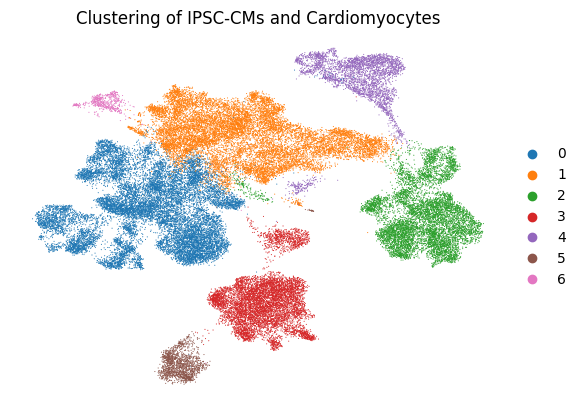

In [6]:
sc.pl.umap(
    adata,
    title = "Clustering of IPSC-CMs and Cardiomyocytes",
    color="leiden",
    frameon=False,
    ncols=1,
    save= "clustering.png"
)

<positron-console-cell-7>:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.


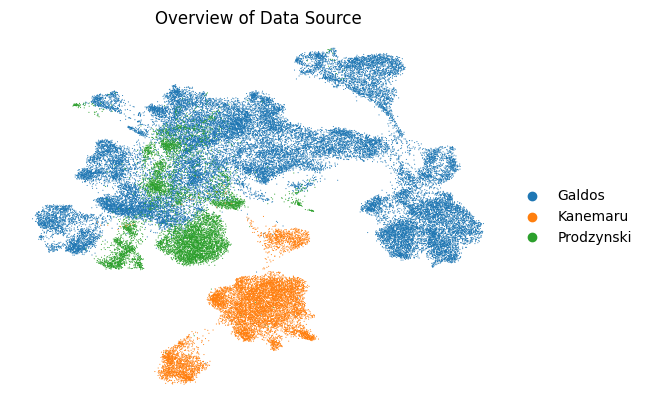

In [7]:
sc.pl.umap(
    adata,
    title = "Overview of Data Source",
    color="source",
    frameon=False,
    ncols=1,
    save = "source.png"
)

<positron-console-cell-8>:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.


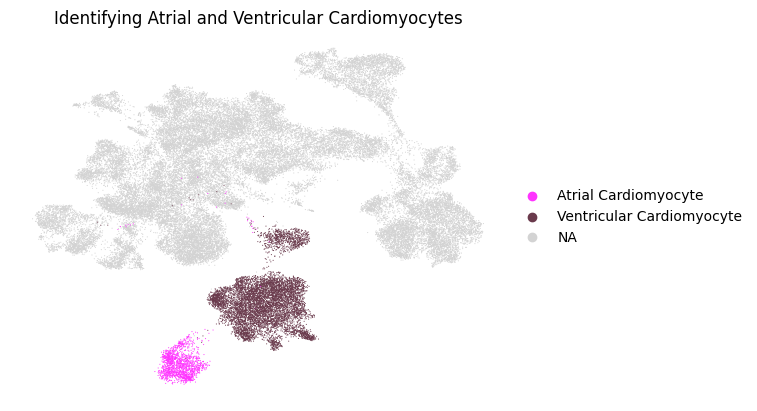

In [8]:
sc.pl.umap(
    adata,
    title = "Identifying Atrial and Ventricular Cardiomyocytes",
    color="condition",
    frameon=False,
    ncols=1,
    groups = ["Atrial Cardiomyocyte", "Ventricular Cardiomyocyte"],
    save = "CMIdent.png"
)

<positron-console-cell-9>:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.


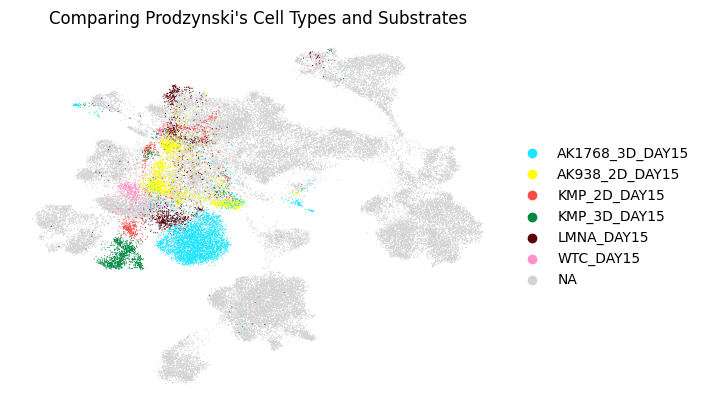

In [9]:
sc.pl.umap(
    adata,
    title = "Comparing Prodzynski's Cell Types and Substrates",
    color="condition",
    frameon=False,
    ncols=1,
    groups = ["KMP_2D_DAY15", "KMP_3D_DAY15", "AK938_2D_DAY15", "AK1768_3D_DAY15",
    "LMNA_DAY15", "WTC_DAY15"],
    save = "ProdIdent.png"
)

In [10]:
annot = sc.queries.biomart_annotations(
    "hsapiens",
    ["ensembl_gene_id", "external_gene_name", "description"],
    host="www.ensembl.org"
)
annot = annot.drop_duplicates(subset=['external_gene_name'], keep='first')
ensembl_to_symbol = annot.set_index("ensembl_gene_id")["external_gene_name"]
ensembl_to_description = annot.set_index("ensembl_gene_id")["description"]

In [11]:
adata.var['geneID'] = adata.var.index.map(ensembl_to_symbol)
adata.var['description'] = adata.var.index.map(ensembl_to_description)
adata.var['ensembl'] = adata.var_names
adata.var_names = adata.var['geneID']

In [12]:
maturity_markers = [
"TNNT2",
"ACTN2",
"MYH6",
"MYH7",
 ]

In [13]:
cluster_map = {
    "0": "Mature iPSC CM",
    "1": "Immature iPSC CM",
    "2": "Undifferentiated iPSC",
    "3": "Ventricular CM",
    "4": "Non CM iPSC",
    "5": "Atrial CM",
    "6": "Non CM iPSC-2"
}
adata.obs["cellLabel"] = adata.obs["leiden"].map(cluster_map)
adata.obs["cellLable"] = adata.obs["cellLabel"].astype("category")

<positron-console-cell-14>:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.


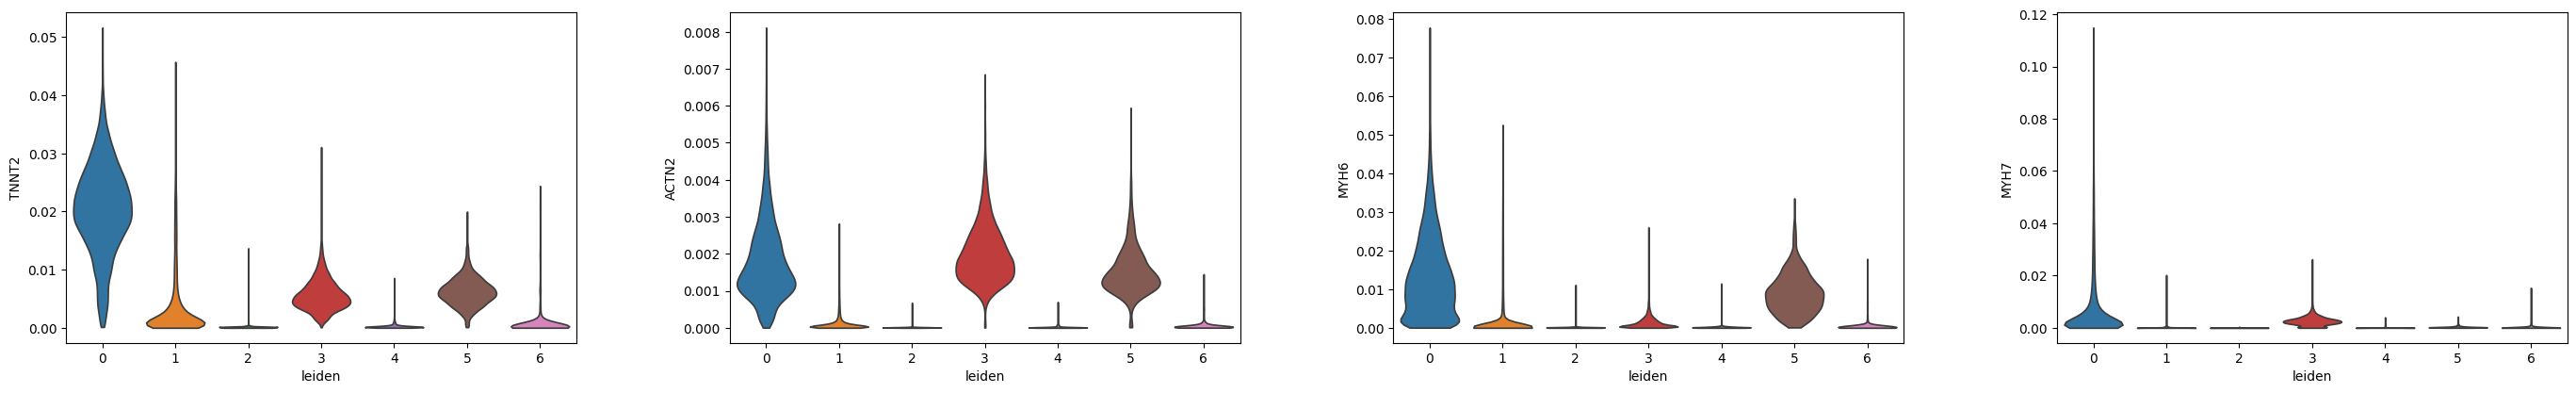

In [14]:
sc.pl.violin(
    adata, 
    maturity_markers, 
    groupby='leiden', 
    layer='SCVI_normalized',
    stripplot=False,
    save = "cm marker violin.png"
)